In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_file_path="/content/drive/MyDrive/archive.zip"
extract_dir="/content"

if os.path.exists(zip_file_path):
  try:
    with zipfile.ZipFile(zip_file_path,'r') as zip_ref:
      zip_ref.extractall(extract_dir)
    print(f"Successfully Extracted '{zip_file_path}' to '{extract_dir}'")
  except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file.")
  except Exception as e:
    print(f"An Error has occured : {e}")
else:
  print(f"Error: '{zip_file_path}' does not exist")

Successfully Extracted '/content/drive/MyDrive/archive.zip' to '/content'


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
import os
import glob as gb
import glob
import cv2
import tensorflow as tf

In [4]:
train='/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train'

In [5]:
size=224
train_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=90,
    width_shift_range=0.0,
    height_shift_range=0.0,
    shear_range=0.0,
    zoom_range=0.0,
    horizontal_flip=False,
    vertical_flip=False,
    rescale=1/255.0,
    preprocessing_function=None,
    validation_split=0.1,
).flow_from_directory(train,
                      batch_size=164,
                      target_size=(size,size),
                      subset="training",
                      color_mode='rgb', #"rgb", "rgba", or "grayscale"
                      class_mode='categorical',  # Use 'binary', 'sparse','categorical' or None as needed
                      shuffle=True)

Found 63282 images belonging to 38 classes.


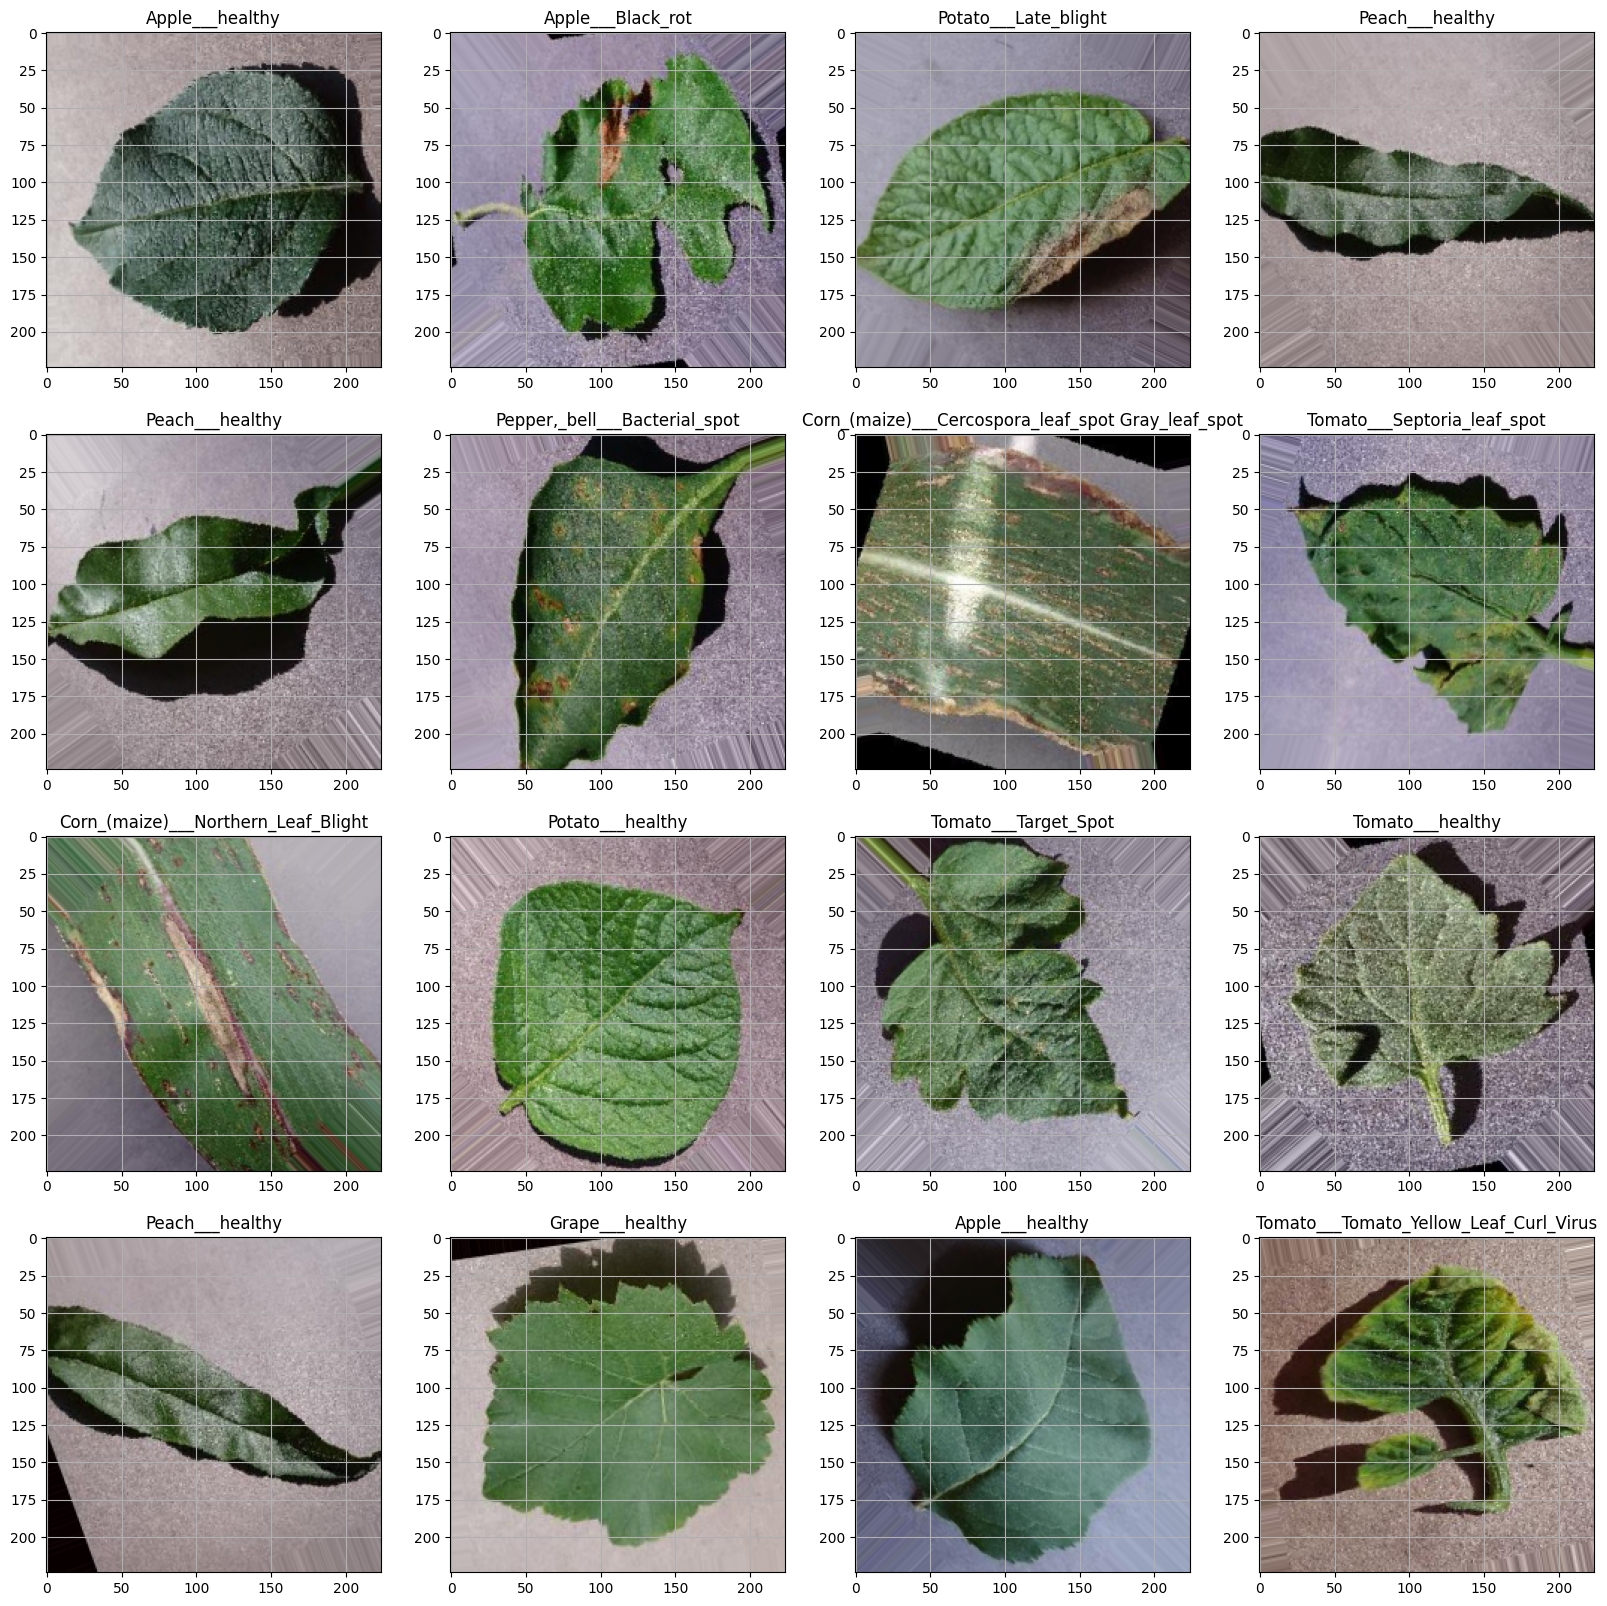

In [6]:
classes=list(train_generator.class_indices.keys())
plt.figure(figsize=(20,20))
for X_batch, y_batch in train_generator:
    for i in range(0,16):
        plt.subplot(4,4,i+1)
        plt.imshow(X_batch[i])
        plt.title(classes[np.where(y_batch[i]==1)[0][0]])
        plt.grid(None)
    plt.show()
    break

In [7]:
valid='/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid'

In [8]:
valid_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    preprocessing_function=None,
    validation_split=0.1,
).flow_from_directory(valid,
                      batch_size=164,
                      target_size=(224,224),
                      subset='validation',
                      color_mode='rgb', #"rgb", "rgba", or "grayscale"
                      class_mode='categorical',  # Use 'binary', 'sparse','categorical' or None as needed
                      shuffle=False)

Found 1742 images belonging to 38 classes.


In [9]:
test='/content/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid'
test_generator=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1/255.0,
    preprocessing_function=None,
).flow_from_directory(test,
                      batch_size=164,
                      target_size=(224,224),
                      color_mode='rgb', #"rgb", "rgba", or "grayscale"
                      class_mode='categorical',  # Use 'binary', 'sparse','categorical' or None as needed
                      shuffle=False)

Found 17572 images belonging to 38 classes.


In [10]:
from tensorflow import keras
model=keras.models.Sequential()
model.add(keras.layers.Conv2D(filters=32,kernel_size=7,strides=1,padding="same",activation="relu",name="Conv1",input_shape=(224,224,3)))
model.add(keras.layers.MaxPool2D(pool_size=2,name="Pool1"))
model.add(keras.layers.Conv2D(filters=64,kernel_size=5,strides=1,padding="same",activation="relu",name="Conv2"))
model.add(keras.layers.MaxPool2D(pool_size=2,name="Pool2"))
model.add(keras.layers.Conv2D(filters=128,kernel_size=3,strides=1,padding="same",activation="relu",name="Conv3"))
model.add(keras.layers.Conv2D(filters=256,kernel_size=3,strides=1,padding="same",activation="relu",name="Conv4"))
model.add(keras.layers.MaxPool2D(pool_size=2,name="Pool3"))

model.add(keras.layers.Flatten(name="Flatten1"))
model.add(keras.layers.Dense(128,activation="relu",name="Dense1"))
tf.keras.layers.Dropout(0.5)
model.add(keras.layers.Dense(64,activation="relu",name="Dense2"))
tf.keras.layers.Dropout(0.5)

model.add(keras.layers.Dense(38,activation="softmax",name="Output"))
print(model.summary())


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                       │ (None, 224, 224, 32)        │           4,736 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool1 (MaxPooling2D)                 │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2 (Conv2D)                       │ (None, 112, 112, 64)        │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool2 (MaxPooling2D)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv3 (Conv2D)                       │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv4 (Conv2D)                       │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Pool3 (MaxPooling2D)                 │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Flatten1 (Flatten)                   │ (None, 200704)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense1 (Dense)                       │ (None, 128)                 │      25,690,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense2 (Dense)                       │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output (Dense)                       │ (None, 38)                  │           2,470 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,125,990 (99.66 MB)

 Trainable params: 26,125,990 (99.66 MB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
early_stopping=EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)
model_checkpoint=ModelCheckpoint('best_model.keras',monitor='val_loss',save_best_only=True)
model_ReduceLROnPlateau=ReduceLROnPlateau(monitor='val_loss',factor=0.1,patience=15,min_lr=0.000001)
callbacks=[early_stopping,model_checkpoint,model_ReduceLROnPlateau]

In [12]:
model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=["accuracy","precision","recall"])

In [13]:
history = model.fit(
    train_generator,
    epochs=3,
    validation_data=valid_generator,
    callbacks=callbacks
)

Epoch 1/3


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


386/386 ━━━━━━━━━━━━━━━━━━━━ 917s 2s/step - accuracy: 0.2550 - loss: 2.7205 - precision: 0.6072 - recall: 0.1201 - val_accuracy: 0.6223 - val_loss: 1.2110 - val_precision: 0.7430 - val_recall: 0.5161 - learning_rate: 0.0010
Epoch 2/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 825s 2s/step - accuracy: 0.6826 - loss: 1.0247 - precision: 0.8052 - recall: 0.5681 - val_accuracy: 0.6923 - val_loss: 1.0074 - val_precision: 0.7700 - val_recall: 0.6303 - learning_rate: 0.0010
Epoch 3/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 819s 2s/step - accuracy: 0.7767 - loss: 0.7044 - precision: 0.8488 - recall: 0.7115 - val_accuracy: 0.7893 - val_loss: 0.6806 - val_precision: 0.8398 - val_recall: 0.7463 - learning_rate: 0.0010


In [14]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


In [15]:
import seaborn as sns
sns.set()

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

precision=history.history['precision']
val_precision=history.history['val_precision']

recall=history.history['recall']
val_recall=history.history['val_recall']

loss=history.history['loss']
val_loss=history.history['val_loss']

epochs = range(1, len(loss)+1)

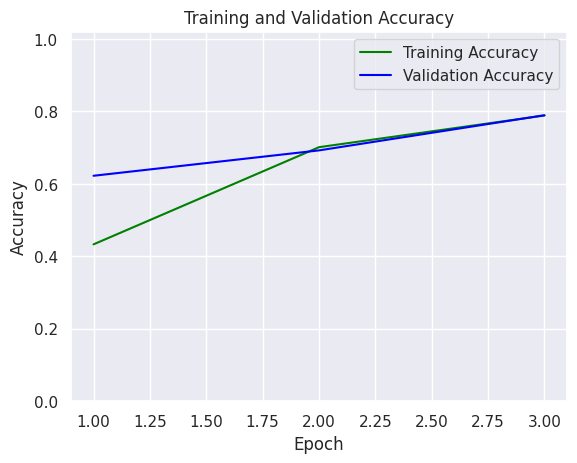

In [16]:
plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim(0, 1.02)
plt.show()

In [17]:
model_evaluate = model.evaluate(test_generator)
print("Loss : ", model_evaluate[0])
print("Accuracy : ", model_evaluate[1])
print("Precision : ", model_evaluate[2])
print("Recall : ", model_evaluate[3])

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


108/108 ━━━━━━━━━━━━━━━━━━━━ 39s 363ms/step - accuracy: 0.7906 - loss: 0.6712 - precision: 0.8431 - recall: 0.7449
Loss :  0.6557345986366272
Accuracy :  0.79347825050354
Precision :  0.8465059399604797
Recall :  0.7472683787345886


In [18]:
model.save('plant_diseases_internship.keras')